Chapter 30
# 二元OLS线性回归
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # 线性回归

## 随机生成数据集

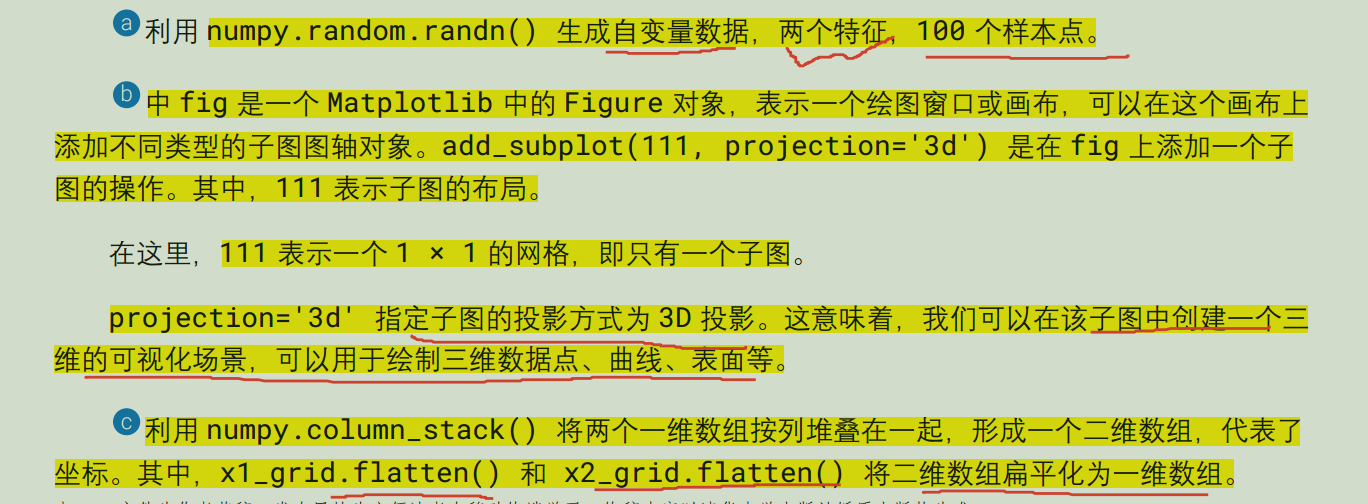

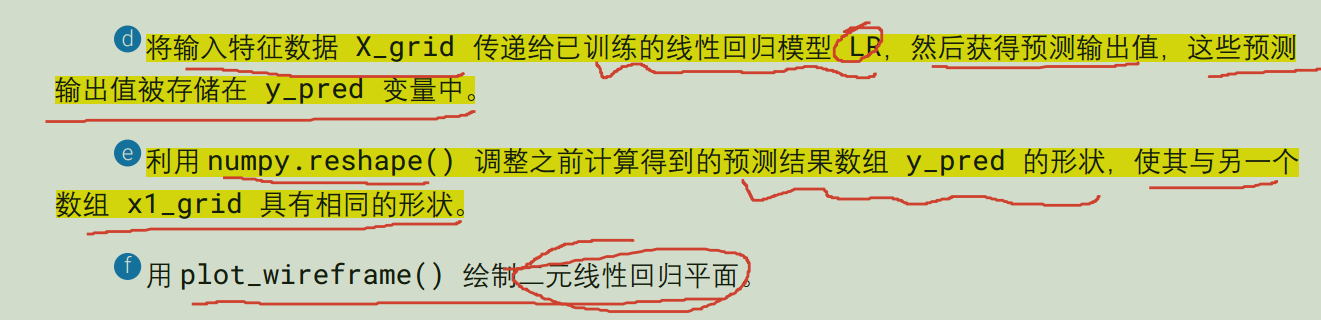

In [2]:
# 随机生成数据集
np.random.seed(0) # 随机种子
n_samples = 100 # 样本数量
X = np.random.randn(n_samples, 2) # 生成一系列点

# 第一二列 干扰项
y = -3 * X[:,0] + 2 * X[:,1] + 1 + 0.5*np.random.randn(n_samples)

In [5]:
X

array([[ 1.76405235,  0.40015721],
       [ 0.97873798,  2.2408932 ],
       [ 1.86755799, -0.97727788],
       [ 0.95008842, -0.15135721],
       [-0.10321885,  0.4105985 ],
       [ 0.14404357,  1.45427351],
       [ 0.76103773,  0.12167502],
       [ 0.44386323,  0.33367433],
       [ 1.49407907, -0.20515826],
       [ 0.3130677 , -0.85409574],
       [-2.55298982,  0.6536186 ],
       [ 0.8644362 , -0.74216502],
       [ 2.26975462, -1.45436567],
       [ 0.04575852, -0.18718385],
       [ 1.53277921,  1.46935877],
       [ 0.15494743,  0.37816252],
       [-0.88778575, -1.98079647],
       [-0.34791215,  0.15634897],
       [ 1.23029068,  1.20237985],
       [-0.38732682, -0.30230275],
       [-1.04855297, -1.42001794],
       [-1.70627019,  1.9507754 ],
       [-0.50965218, -0.4380743 ],
       [-1.25279536,  0.77749036],
       [-1.61389785, -0.21274028],
       [-0.89546656,  0.3869025 ],
       [-0.51080514, -1.18063218],
       [-0.02818223,  0.42833187],
       [ 0.06651722,

In [4]:
y

array([-3.67643354,  2.42588286, -6.00739993, -1.8253478 ,  2.45091932,
        2.66793828, -1.0519262 , -0.0332565 , -3.75259145, -1.69646978,
       10.42129609, -2.91902953, -8.32483124,  0.2551472 , -1.13184323,
        1.08645792, -0.3067459 ,  2.54601025,  0.84354213,  1.53624638,
        0.82765052,  9.84737047,  1.42100995,  6.55410753,  4.64581448,
        4.49183568,  0.24940431,  2.05730094,  1.10673409,  2.05852308,
        1.58624457, -0.2597863 , -0.60727104,  7.02418458,  3.24769467,
       -0.53870681, -4.14061142, -2.61163762,  2.66782148,  2.3854423 ,
        5.97838398, -3.6681106 ,  0.26058148, -3.04508382,  6.16665483,
        3.81641908,  2.90461892,  1.88385644,  4.1335588 ,  0.69003028,
       -7.08443778,  6.46235443,  8.47758917,  0.58628311, -1.46202712,
       -2.44321299,  7.04100827,  2.71724093, -2.94324529,  1.30736492,
       -2.9225078 ,  2.50464909,  2.48627748,  5.97770446, -1.1701005 ,
        4.4826359 ,  3.34860461,  4.30461587, -1.30181305, -2.32

# 创建线性回归模型并拟合数据

In [7]:
# 创建线性回归模型并拟合数据
LR = LinearRegression()
y_predicted = LR.fit(X, y) # 拟合数据

In [10]:
print(type(y_predicted))

<class 'sklearn.linear_model._base.LinearRegression'>


In [8]:
y_predicted

LinearRegression()

In [11]:
slope = LR.coef_ # 斜率
intercept = LR.intercept_ # 截距

In [12]:
print(slope) # 有两个系数；两个自变量
print(intercept)  # 截距

[-2.94476755  1.97298145]
0.974294437405637


##绘制图像

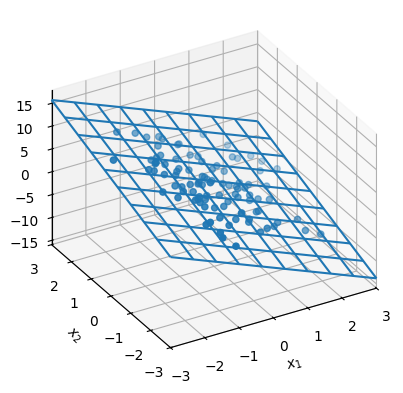

In [13]:
fig = plt.figure()
# projection='3d' 指定子图的投影方式为 3D 投影。
# 这意味着，我们可以在该子图中创建一个三维的可视化场景，可以用于绘制三维数据点、曲线、表面等。
ax = fig.add_subplot(111, projection='3d')

# 原始数据
# 绘制三维样本散点
ax.scatter(X[:,0], X[:,1], y)

# 生成回归平面的数据点
x1_grid, x2_grid = np.meshgrid(np.linspace(-3, 3, 10),
                               np.linspace(-3, 3, 10))

# 展为一维数组
'''
利用 numpy.column_stack() 将两个一维数组按列堆叠在一起，形成一个二维数组，代表了
坐标。其中，x1_grid.flatten() 和 x2_grid.flatten() 将二维数组扁平化为一维数组。
'''
# 每一行就是一个点
X_grid=np.column_stack((x1_grid.flatten(),x2_grid.flatten()))

# 预测回归平面上的响应变量
y_pred = LR.predict(X_grid) # 预测坐标点在 回归线的值
y_pred = y_pred.reshape(x1_grid.shape) # 将数据形状转为 10*10

# 绘制回归平面
# 参数需要二维数组
ax.plot_wireframe(x1_grid, x2_grid, y_pred)

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$') # 标签
ax.set_zlabel('y')
ax.set_xlim([-3,3]); ax.set_ylim([-3,3]) # 范围

# 正交投影
ax.set_proj_type('ortho'); ax.view_init(azim=-120, elev=30) # 视角

可以固定一个x1的值；可以画出一条直线；再次设置一个x1的值
将直线平移就是一个面